In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ----- Dataset -----
np.random.seed(0)
X = np.random.randn(200, 2)
X

array([[ 1.76405235,  0.40015721],
       [ 0.97873798,  2.2408932 ],
       [ 1.86755799, -0.97727788],
       [ 0.95008842, -0.15135721],
       [-0.10321885,  0.4105985 ],
       [ 0.14404357,  1.45427351],
       [ 0.76103773,  0.12167502],
       [ 0.44386323,  0.33367433],
       [ 1.49407907, -0.20515826],
       [ 0.3130677 , -0.85409574],
       [-2.55298982,  0.6536186 ],
       [ 0.8644362 , -0.74216502],
       [ 2.26975462, -1.45436567],
       [ 0.04575852, -0.18718385],
       [ 1.53277921,  1.46935877],
       [ 0.15494743,  0.37816252],
       [-0.88778575, -1.98079647],
       [-0.34791215,  0.15634897],
       [ 1.23029068,  1.20237985],
       [-0.38732682, -0.30230275],
       [-1.04855297, -1.42001794],
       [-1.70627019,  1.9507754 ],
       [-0.50965218, -0.4380743 ],
       [-1.25279536,  0.77749036],
       [-1.61389785, -0.21274028],
       [-0.89546656,  0.3869025 ],
       [-0.51080514, -1.18063218],
       [-0.02818223,  0.42833187],
       [ 0.06651722,

/home/ahmad/.local/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


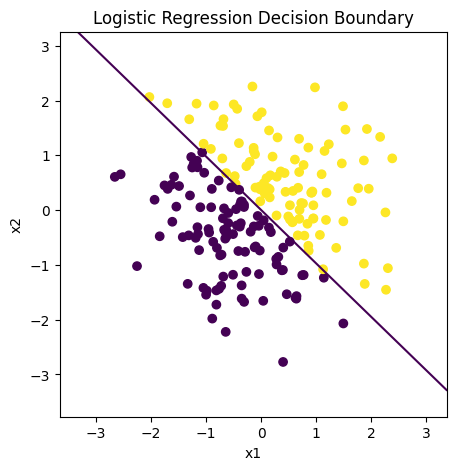

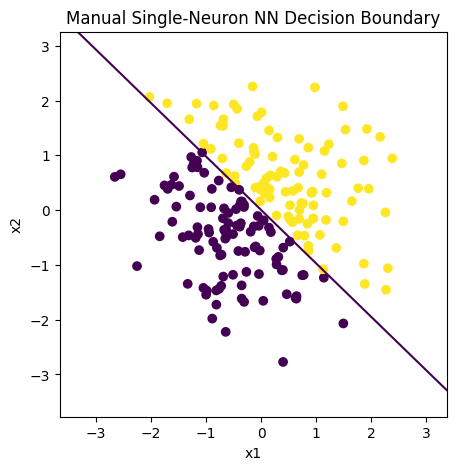

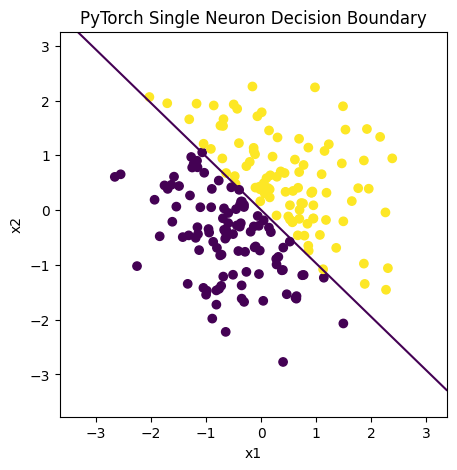

In [1]:
y = (X[:, 0] + X[:, 1] > 0).astype(int).reshape(-1, 1)
n, d = X.shape

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ----- Logistic Regression -----
def train_lr(X, y, lr=0.1, epochs=2000):
    n, d = X.shape
    W = np.zeros((d, 1))
    b = 0.0
    for _ in range(epochs):
        z = X @ W + b
        p = sigmoid(z)
        dW = (1/n) * X.T @ (p - y)
        db = (1/n) * np.sum(p - y)
        W -= lr * dW
        b -= lr * db
    return W, b

W_lr, b_lr = train_lr(X, y)

# ----- Manual Single Neuron NN -----
def train_nn(X, y, lr=0.1, epochs=2000):
    n, d = X.shape
    W = np.zeros((d, 1))
    b = 0.0
    for _ in range(epochs):
        z = X @ W + b
        a = sigmoid(z)
        dW = (1/n) * X.T @ (a - y)
        db = (1/n) * np.sum(a - y)
        W -= lr * dW
        b -= lr * db
    return W, b

W_nn, b_nn = train_nn(X, y)

# ----- PyTorch Neuron -----
class SingleNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

torch.manual_seed(0)
model = SingleNeuron()
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)

for _ in range(2000):
    optimizer.zero_grad()
    pred = model(X_t)
    loss = criterion(pred, y_t)
    loss.backward()
    optimizer.step()

W_t = model.linear.weight.detach().numpy().reshape(-1, 1)
b_t = model.linear.bias.detach().numpy()[0]

# ----- Grid for decision boundary -----
xs = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200)
ys = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200)
xx, yy = np.meshgrid(xs, ys)
grid = np.c_[xx.ravel(), yy.ravel()]

def decision_boundary(W, b):
    z = grid @ W + b
    p = sigmoid(z)
    return p.reshape(xx.shape)

Z_lr = decision_boundary(W_lr, b_lr)
Z_nn = decision_boundary(W_nn, b_nn)
Z_t  = decision_boundary(W_t,  b_t)

# ----- Plot 1: Logistic Regression -----
plt.figure(figsize=(5, 5))
plt.contour(xx, yy, Z_lr, levels=[0.5])
plt.scatter(X[:, 0], X[:, 1], c=y.ravel())
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# ----- Plot 2: Manual Neural Neuron -----
plt.figure(figsize=(5, 5))
plt.contour(xx, yy, Z_nn, levels=[0.5])
plt.scatter(X[:, 0], X[:, 1], c=y.ravel())
plt.title("Manual Single-Neuron NN Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# ----- Plot 3: PyTorch Neuron -----
plt.figure(figsize=(5, 5))
plt.contour(xx, yy, Z_t, levels=[0.5])
plt.scatter(X[:, 0], X[:, 1], c=y.ravel())
plt.title("PyTorch Single Neuron Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()